# Mini Project 5-4 Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [2]:
# Import relevant packages

import pandas as pd
import numpy as np

### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [6]:
# Import data
air_quality = pd.read_csv('c4_epa_air_quality.csv')
air_quality = air_quality.dropna()

## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [26]:
# Code Here
air_quality.head()

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


In [ ]:
# Code Here


In [ ]:
# Code Here

**Question:** What time range does this data cover?

In [30]:
# Code Here
air_quality['date_local'].head(258)

0      2018-01-01
1      2018-01-01
2      2018-01-01
3      2018-01-01
4      2018-01-01
          ...    
254    2018-01-01
255    2018-01-01
256    2018-01-01
257    2018-01-01
259    2018-01-01
Name: date_local, Length: 257, dtype: object

A: First day of 2018

**Question:** What are the minimum and maximum AQI values observed in the dataset?

In [36]:
# Code Here
print(air_quality['aqi'].max())
print(air_quality['aqi'].min())

50
0


**Question:** Are all states equally represented in the dataset?

In [62]:
# Code Here
air_quality['state_name'].value_counts()

state_name
California              66
Arizona                 14
Ohio                    12
Florida                 12
Texas                   10
New York                10
Pennsylvania             9
Michigan                 9
Colorado                 9
Minnesota                7
New Jersey               6
Indiana                  5
North Carolina           4
Massachusetts            4
Maryland                 4
Oklahoma                 4
Virginia                 4
Nevada                   4
Connecticut              4
Kentucky                 3
Missouri                 3
Wyoming                  3
Iowa                     3
Hawaii                   3
Utah                     3
Vermont                  3
Illinois                 3
New Hampshire            2
District Of Columbia     2
New Mexico               2
Oregon                   2
Montana                  2
Alaska                   2
Tennessee                2
Washington               2
Idaho                    2
Rhode Island     

A: Not all states are represented equally

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

In [174]:
# Summarize the mean AQI for RRE states.

air_quality_df = pd.DataFrame(air_quality)
air_quality_rre = air_quality_df['state_name'].str.contains('California|Florida|Michigan|Ohio|Pennsylvania|Texas')
air_quality_rre.mean()

# Create a list of RRE states.

air_quality_rre_states = ['California', 'Florida', 'Michigan', 'Ohio', 'Pennsylvania', 'Texas']
# Subset `aqi` to only consider these states.

air_quality_rre_aqi = air_quality_df[air_quality_df['state_name'].isin(air_quality_rre_states)]

# Find the mean aqi for each of the RRE states.
 #alias as aqi_rre

c


,aqi,state_name
state_name,,
California,12.121212,66
Florida,5.500000,12
Michigan,8.111111,9
Ohio,3.333333,12
Pennsylvania,3.000000,9
Texas,2.700000,10


In [80]:
# Import seaborn as sns.

import seaborn as sns

### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

<Axes: xlabel='state_name', ylabel='aqi'>

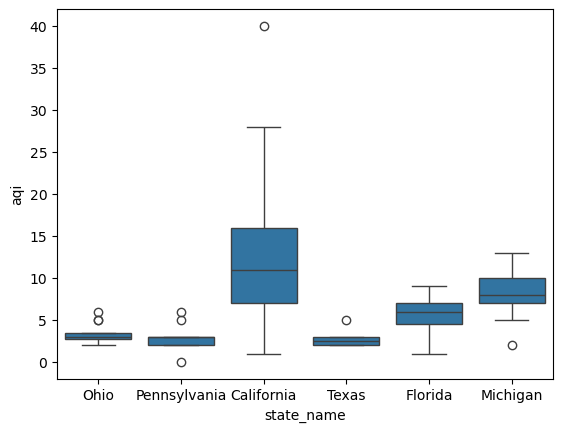

In [178]:
# Code Here

sns.boxplot(x=air_quality_rre_aqi['state_name'],y=air_quality_rre_aqi['aqi'])

**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

A:

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for your state.

In [204]:
# Find the mean aqi for your state.


cali_df = air_quality[air_quality['state_name'] == 'California']
cali_df['aqi'].mean()

12.121212121212121

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [15]:
# Input your confidence level here:

95%

### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [216]:
# Calculate your margin of error.

# Begin by identifying the z associated with your chosen confidence level.

z_value = 1.96

# Next, calculate your standard error.
print(cali_df['aqi'].std())
cali_se = cali_df['aqi'].std()/(len(cali_df)**0.5)
# Lastly, use the preceding result to calculate your margin of error.



7.301243627503367


### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [224]:
# Calculate your confidence interval (upper and lower limits).

upper_limit = cali_df['aqi'].mean() + cali_se
lower_limit = cali_df['aqi'].mean() - cali_se
print(lower_limit, ",", upper_limit)

11.22249115709938 , 13.019933085324862


### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [230]:
# Import stats from scipy.
import scipy
from scipy import stats

## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [234]:
# Code Here
confidence_level = 0.95
sample_mean = cali_df['aqi'].mean()
standard_error = cali_se
scipy.stats.norm.interval(confidence_level, sample_mean, standard_error)

(10.359751399400034, 13.882672843024208)

# Considerations

**What are some key takeaways that you learned from this project?**

A: learned how to make boxplots, calculate z scores, and confidence intervals

**What findings would you share with others?**

A: 95% of the randomly sampled aqi values from california would fall in between 10.3598 and 13.8827.

**What would you convey to external readers?**

A: Shows the steps and processes to get the proper data needed to conduct statistical analysis

**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 